In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/Orgo4ever/data-wrangling-project/main/Data/Raw%20data/eurostat_renewable_energy_share.csv"

df = pd.read_csv(url)

df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,nrg_bal,Energy balance,unit,Unit of measure,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:NRG_IND_REN$DEFAULTVIEW(1.0),Share of energy from renewable sources,A,Annual,REN,Renewable energy - overall,PC,Percentage,AL,Albania,2015,NaN,34.913,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:NRG_IND_REN$DEFAULTVIEW(1.0),Share of energy from renewable sources,A,Annual,REN,Renewable energy - overall,PC,Percentage,AL,Albania,2016,NaN,36.953,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:NRG_IND_REN$DEFAULTVIEW(1.0),Share of energy from renewable sources,A,Annual,REN,Renewable energy - overall,PC,Percentage,AL,Albania,2017,NaN,35.776,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:NRG_IND_REN$DEFAULTVIEW(1.0),Share of energy from renewable sources,A,Annual,REN,Renewable energy - overall,PC,Percentage,AL,Albania,2018,NaN,36.572,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:NRG_IND_REN$DEFAULTVIEW(1.0),Share of energy from renewable sources,A,Annual,REN,Renewable energy - overall,PC,Percentage,AL,Albania,2019,NaN,38.042,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,nrg_bal,Energy balance,unit,Unit of measure,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True,True,True
378,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True,True,True
379,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True,True,True
380,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,True,True,True


In [5]:
df.isnull().sum() / len(df) * 100

STRUCTURE                                   0.0
STRUCTURE_ID                                0.0
STRUCTURE_NAME                              0.0
freq                                        0.0
Time frequency                              0.0
nrg_bal                                     0.0
Energy balance                              0.0
unit                                        0.0
Unit of measure                             0.0
geo                                         0.0
Geopolitical entity (reporting)             0.0
TIME_PERIOD                                 0.0
Time                                      100.0
OBS_VALUE                                   0.0
Observation value                         100.0
OBS_FLAG                                  100.0
Observation status (Flag) V2 structure    100.0
CONF_STATUS                               100.0
Confidentiality status (flag)             100.0
dtype: float64

In [6]:
df.isna().sum()

STRUCTURE                                   0
STRUCTURE_ID                                0
STRUCTURE_NAME                              0
freq                                        0
Time frequency                              0
nrg_bal                                     0
Energy balance                              0
unit                                        0
Unit of measure                             0
geo                                         0
Geopolitical entity (reporting)             0
TIME_PERIOD                                 0
Time                                      382
OBS_VALUE                                   0
Observation value                         382
OBS_FLAG                                  382
Observation status (Flag) V2 structure    382
CONF_STATUS                               382
Confidentiality status (flag)             382
dtype: int64

In [10]:
df = df.dropna(axis=1, how="all")

In [12]:
df.shape

(382, 13)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   STRUCTURE                        382 non-null    str    
 1   STRUCTURE_ID                     382 non-null    str    
 2   STRUCTURE_NAME                   382 non-null    str    
 3   freq                             382 non-null    str    
 4   Time frequency                   382 non-null    str    
 5   nrg_bal                          382 non-null    str    
 6   Energy balance                   382 non-null    str    
 7   unit                             382 non-null    str    
 8   Unit of measure                  382 non-null    str    
 9   geo                              382 non-null    str    
 10  Geopolitical entity (reporting)  382 non-null    str    
 11  TIME_PERIOD                      382 non-null    int64  
 12  OBS_VALUE                        

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

STRUCTURE                            1
STRUCTURE_ID                         1
STRUCTURE_NAME                       1
freq                                 1
Time frequency                       1
nrg_bal                              1
Energy balance                       1
unit                                 1
Unit of measure                      1
geo                                 40
Geopolitical entity (reporting)     40
TIME_PERIOD                         10
OBS_VALUE                          377
dtype: int64

In [16]:
df = df.drop(columns=[
    "STRUCTURE",
    "STRUCTURE_ID",
    "STRUCTURE_NAME",
    "freq",
    "Time frequency",
    "nrg_bal",
    "Energy balance",
    "unit",
    "Unit of measure"
])

In [17]:
df = df.rename(columns={
    "Geopolitical entity (reporting)": "country",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "renewable_energy_share"
})

In [18]:
df.head()

,geo,country,year,renewable_energy_share
0,AL,Albania,2015,34.913
1,AL,Albania,2016,36.953
2,AL,Albania,2017,35.776
3,AL,Albania,2018,36.572
4,AL,Albania,2019,38.042


In [19]:
df.head(10)

,geo,country,year,renewable_energy_share
0,AL,Albania,2015,34.913
1,AL,Albania,2016,36.953
2,AL,Albania,2017,35.776
3,AL,Albania,2018,36.572
4,AL,Albania,2019,38.042
5,AL,Albania,2020,45.015
6,AL,Albania,2021,41.389
7,AL,Albania,2022,44.076
8,AL,Albania,2023,46.620
9,AL,Albania,2024,43.111


In [20]:
df.tail()

,geo,country,year,renewable_energy_share
377,XK,Kosovo*,2020,24.401
378,XK,Kosovo*,2021,22.061
379,XK,Kosovo*,2022,18.773
380,XK,Kosovo*,2023,20.215
381,XK,Kosovo*,2024,18.020


In [21]:
df

,geo,country,year,renewable_energy_share
0,AL,Albania,2015,34.913
1,AL,Albania,2016,36.953
2,AL,Albania,2017,35.776
3,AL,Albania,2018,36.572
4,AL,Albania,2019,38.042
...,...,...,...,...
377,XK,Kosovo*,2020,24.401
378,XK,Kosovo*,2021,22.061
379,XK,Kosovo*,2022,18.773
380,XK,Kosovo*,2023,20.215


In [22]:
df.to_csv("cleaned_renewable_energy.csv", index=False)

In [23]:
df = df.rename(columns={"geo": "country_code"})

In [24]:
df = df.sort_values(["country", "year"])

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 382 entries, 0 to 351
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country_code            382 non-null    str    
 1   country                 382 non-null    str    
 2   year                    382 non-null    int64  
 3   renewable_energy_share  382 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 14.9 KB


In [26]:
df = df.reset_index(drop=True)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country_code            382 non-null    str    
 1   country                 382 non-null    str    
 2   year                    382 non-null    int64  
 3   renewable_energy_share  382 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 12.1 KB


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df["country"].unique()

<StringArray>
[                                  'Albania',
                                   'Austria',
                                   'Belgium',
                    'Bosnia and Herzegovina',
                                  'Bulgaria',
                                   'Croatia',
                                    'Cyprus',
                                   'Czechia',
                                   'Denmark',
                                   'Estonia',
      'Euro area – 20 countries (2023-2025)',
      'Euro area – 21 countries (from 2026)',
 'European Union - 27 countries (from 2020)',
                                   'Finland',
                                    'France',
                                   'Georgia',
                                   'Germany',
                                    'Greece',
                                   'Hungary',
                                   'Iceland',
                                   'Ireland',
                    

In [31]:
df["year"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [32]:
df["renewable_energy_share"].describe()

count    382.000000
mean      27.420469
std       16.146516
min        4.987000
25%       17.132000
50%       22.572500
75%       35.093750
max       83.725000
Name: renewable_energy_share, dtype: float64

In [ ]:
#summary

Here's a short summary of your cleaned dataset:

Dataset overview
Rows: 382
Columns: 4
Missing values: None ✅
Duplicate information: Each row represents one country in one year.
Variables
Column	Type	Description
geo	Text	Country code (e.g. AL)
country	Text	Country name
year	Integer	Year of the observation
renewable_energy_share	Float	Percentage of renewable energy share
Time coverage
From: 2015
To: 2024
Countries: 40
Renewable energy share statistics
Average: 27.42%
Median: 22.57%
Minimum: 4.99%
Maximum: 83.73%
25th percentile: 17.13%
75th percentile: 35.09%
Data quality
✅ No missing values.
✅ Correct data types (year as integer and renewable_energy_share as numeric).
✅ Clean and ready for analysis and visualization.
Possible analyses

With this dataset you can:

Analyze how renewable energy share changes over time (2015–2024).
Compare countries' renewable energy adoption.
Identify countries with the highest and lowest renewable energy shares.
Calculate trends or growth rates by country.
Create line charts, bar charts, heatmaps, or maps of renewable energy usage.

This dataset is well-structured for time series and cross-country comparisons.

In [ ]:
#The next phase is EDA (Exploratory Data Analysis):

#1.How renewable is Europe's electricity? -> Which countries have the highest renewable energy share?
#2.Is Europe becoming greener over time? -> How has renewable energy share changed over time?
#3. Which countries are improving the fastest? -> hich countries have seen the biggest increase?
#These are all useful because they establish whether Europe's energy system is becoming cleaner—the context needed before talking about AI

In [ ]:
#Then, when you merge with your AI dataset, you answer the real question:
    #·Where are AI data centers located?
    #·Do those countries rely on renewable energy?
    #·Is AI expanding in countries with cleaner electricity?
    #·Is renewable energy growing fast enough to support AI's increasing electricity demand?

In [ ]:
#Think of your project like a story

#Chapter 1 – Renewable energy (this dataset)

    #Is Europe getting greener?

#Chapter 2 – AI infrastructure

    #Where is AI growing?

#Chapter 3 – Merge

    #Does AI growth align with clean energy, or is it increasing pressure on fossil-fuel-based electricity?

#That third chapter is where you answer "Is Europe's AI boom environmentally sustainable?" 
#The first two chapters provide the evidence needed to reach that conclusion.

In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/Orgo4ever/data-wrangling-project/refs/heads/main/Data/Raw%20data/eurostat_power_sector_emissions.csv"

df2 = pd.read_csv(url)

df2.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,airpol,Air pollutants and greenhouse gases,src_crf,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:ENV_AIR_GGE$DEFAULTVIEW(1.0),Greenhouse gas emissions by source sector,A,Annual,MIO_T,Million tonnes,CH4,Methane,CRF1,...,AT,Austria,2015,NaN,0.03087,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:ENV_AIR_GGE$DEFAULTVIEW(1.0),Greenhouse gas emissions by source sector,A,Annual,MIO_T,Million tonnes,CH4,Methane,CRF1,...,AT,Austria,2016,NaN,0.03084,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:ENV_AIR_GGE$DEFAULTVIEW(1.0),Greenhouse gas emissions by source sector,A,Annual,MIO_T,Million tonnes,CH4,Methane,CRF1,...,AT,Austria,2017,NaN,0.03199,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:ENV_AIR_GGE$DEFAULTVIEW(1.0),Greenhouse gas emissions by source sector,A,Annual,MIO_T,Million tonnes,CH4,Methane,CRF1,...,AT,Austria,2018,NaN,0.02887,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:ENV_AIR_GGE$DEFAULTVIEW(1.0),Greenhouse gas emissions by source sector,A,Annual,MIO_T,Million tonnes,CH4,Methane,CRF1,...,AT,Austria,2019,NaN,0.02811,NaN,NaN,NaN,NaN,NaN


In [8]:
df2.isnull()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,airpol,Air pollutants and greenhouse gases,src_crf,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,True,True,True,True
15996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,True,True,True,True
15997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,True,True,True,True
15998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,True,True,True,True


In [9]:
df2.isnull().sum() / len(df2) * 100

STRUCTURE                                                                          0.0
STRUCTURE_ID                                                                       0.0
STRUCTURE_NAME                                                                     0.0
freq                                                                               0.0
Time frequency                                                                     0.0
unit                                                                               0.0
Unit of measure                                                                    0.0
airpol                                                                             0.0
Air pollutants and greenhouse gases                                                0.0
src_crf                                                                            0.0
Source sectors for greenhouse gas emissions (Common reporting format, UNFCCC)      0.0
geo                                        

In [10]:
df2.isna().sum()

STRUCTURE                                                                            0
STRUCTURE_ID                                                                         0
STRUCTURE_NAME                                                                       0
freq                                                                                 0
Time frequency                                                                       0
unit                                                                                 0
Unit of measure                                                                      0
airpol                                                                               0
Air pollutants and greenhouse gases                                                  0
src_crf                                                                              0
Source sectors for greenhouse gas emissions (Common reporting format, UNFCCC)        0
geo                                        

In [11]:
df2 = df2.drop(columns=[
    "Time",
    "Observation value",
    "OBS_FLAG",
    "Observation status (Flag) V2 structure",
    "CONF_STATUS",
    "Confidentiality status (flag)"
])

In [12]:
df2 = df2.drop(columns=[
    "STRUCTURE",
    "STRUCTURE_ID",
    "STRUCTURE_NAME",
    "freq",
    "Time frequency",
    "unit",
    "Unit of measure"
])

In [14]:
df2 = df2.rename(columns={
    "Air pollutants and greenhouse gases": "gas_name",
    "airpol": "gas",
    "Source sectors for greenhouse gas emissions (Common reporting format, UNFCCC)": "sector_name",
    "src_crf": "sector",
    "Geopolitical entity (reporting)": "country",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "emissions"
})

In [15]:
df2.duplicated().sum()

np.int64(35)

In [16]:
df2[df2.duplicated()]

,gas,gas_name,sector,sector_name,geo,country,year,emissions
8810,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2015,0.0
8811,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2016,0.0
8812,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2017,0.0
8813,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2018,0.0
8814,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2019,0.0
8815,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2020,0.0
8816,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2021,0.0
8817,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2022,0.0
8818,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2023,0.0
8819,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2024,0.0


In [17]:
df2[df2.duplicated(keep=False)]

,gas,gas_name,sector,sector_name,geo,country,year,emissions
810,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2015,0.0
811,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2016,0.0
812,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2017,0.0
813,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2018,0.0
814,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2019,0.0
...,...,...,...,...,...,...,...,...
15265,N2O,Nitrous oxide,CRF1A1,Fuel combustion in energy industries,MT,Malta,2020,0.0
15266,N2O,Nitrous oxide,CRF1A1,Fuel combustion in energy industries,MT,Malta,2021,0.0
15267,N2O,Nitrous oxide,CRF1A1,Fuel combustion in energy industries,MT,Malta,2022,0.0
15268,N2O,Nitrous oxide,CRF1A1,Fuel combustion in energy industries,MT,Malta,2023,0.0


In [18]:
df2[df2.duplicated(keep=False)].sort_values(
    by=["gas", "sector", "geo", "year"]
)

,gas,gas_name,sector,sector_name,geo,country,year,emissions
810,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2015,0.0
8810,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2015,0.0
811,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2016,0.0
8811,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2016,0.0
812,CH4,Methane,CRF1A1,Fuel combustion in energy industries,IS,Iceland,2017,0.0
...,...,...,...,...,...,...,...,...
15267,N2O,Nitrous oxide,CRF1A1,Fuel combustion in energy industries,MT,Malta,2022,0.0
7268,N2O,Nitrous oxide,CRF1A1,Fuel combustion in energy industries,MT,Malta,2023,0.0
15268,N2O,Nitrous oxide,CRF1A1,Fuel combustion in energy industries,MT,Malta,2023,0.0
7269,N2O,Nitrous oxide,CRF1A1,Fuel combustion in energy industries,MT,Malta,2024,0.0


In [19]:
df2 = df2.drop_duplicates()

In [20]:
df2.duplicated().sum()

np.int64(0)

In [21]:
df2["gas"].unique()

df2["sector"].unique()

df2["year"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [22]:
df2 = df2[df2["gas"] == "CO2"]

In [23]:
df2 = df2.reset_index(drop=True)

In [24]:
df2.head()

df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   gas          3200 non-null   str    
 1   gas_name     3200 non-null   str    
 2   sector       3200 non-null   str    
 3   sector_name  3200 non-null   str    
 4   geo          3200 non-null   str    
 5   country      3200 non-null   str    
 6   year         3200 non-null   int64  
 7   emissions    3200 non-null   float64
dtypes: float64(1), int64(1), str(6)
memory usage: 200.1 KB


In [25]:
df2["gas"].value_counts()

gas
CO2    3200
Name: count, dtype: int64

In [26]:
df2["sector"].value_counts()

sector
CRF1          640
CRF1A         640
CRF1A1        640
TOTX4_MEMO    640
TOTXMEMO      640
Name: count, dtype: int64

In [27]:
df2 = df2[df2["sector"] == "CRF1A1"].reset_index(drop=True)

In [28]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   gas          640 non-null    str    
 1   gas_name     640 non-null    str    
 2   sector       640 non-null    str    
 3   sector_name  640 non-null    str    
 4   geo          640 non-null    str    
 5   country      640 non-null    str    
 6   year         640 non-null    int64  
 7   emissions    640 non-null    float64
dtypes: float64(1), int64(1), str(6)
memory usage: 40.1 KB


In [30]:
df2.to_csv("clean_eurostat_power_sector_emissions.csv", index=False)

In [ ]:
#You now have a clean emissions dataset (640 records, 8 variables) that is ready for analysis.

📊 What the dataset contains
Each row represents emissions data for a specific gas, sector, country, and year.

🌍 Dimensions covered
Countries (geo + country name)

Years (time dimension)

Greenhouse gases (like CO2 and others)

Economic/industrial sectors (coded + named)

🧩 Structure of the data
Gas is recorded both as a code and a readable name

Sector is also duplicated as code + description

Countries are also stored as code + full name

Emissions are stored as a numeric value (float) → this is your key metric

📈 What this dataset lets you analyze
You can now easily study:

How emissions change over time (by year)

Which countries emit more or less

Which sectors contribute most to emissions

Which gases dominate total emissions (e.g. CO2 vs others)

Comparisons between industries and countries

🧠 Big picture
This dataset is basically a structured map of greenhouse gas emissions across Europe, broken down by:
👉 time
👉 geography
👉 sector
👉 gas type

So it's perfect for:

trend analysis

environmental impact comparisons

policy insights (which sectors/countries to target)

In [42]:
#merged datasets

import pandas as pd

grouped_df = pd.read_csv("grouped_df.csv")


grouped_df.head()

,geo,year,emissions,renewable_energy_share,ai_adoption_pct
0,AT,2021,8.56969,34.643,8.83
1,AT,2023,7.18464,41.600,10.79
2,AT,2024,7.14749,42.951,20.27
3,BE,2021,18.01829,13.017,10.32
4,BE,2023,15.52537,14.673,13.81


In [43]:
# Make sure grouped_df has matching formats
grouped_df["geo"] = grouped_df["geo"].astype(str).str.strip().str.upper()
grouped_df["year"] = pd.to_numeric(grouped_df["year"], errors="coerce").astype(int)

grouped_df.head()

,geo,year,emissions,renewable_energy_share,ai_adoption_pct
0,AT,2021,8.56969,34.643,8.83
1,AT,2023,7.18464,41.600,10.79
2,AT,2024,7.14749,42.951,20.27
3,BE,2021,18.01829,13.017,10.32
4,BE,2023,15.52537,14.673,13.81


In [44]:
import pandas as pd

# Load the merged dataset
grouped_df = pd.read_csv("grouped_df.csv")

# Make sure formats are correct
grouped_df["geo"] = grouped_df["geo"].astype(str).str.strip().str.upper()
grouped_df["year"] = pd.to_numeric(grouped_df["year"], errors="coerce").astype(int)

# Sort the dataframe
grouped_df = (
    grouped_df
    .sort_values(["geo", "year"])
    .reset_index(drop=True)
)

grouped_df.head()

,geo,year,emissions,renewable_energy_share,ai_adoption_pct
0,AT,2021,8.56969,34.643,8.83
1,AT,2021,8569.69000,34.643,8.83
2,AT,2023,7.18464,41.600,10.79
3,AT,2023,7184.64000,41.600,10.79
4,AT,2024,7.14749,42.951,20.27


In [ ]:
#Part 6 — Correlation Analysis
Create a correlation heatmap for:
• AI Adoption
• Renewable Energy %
• CO₂ Emissions

#Possible questions:
• Does renewable energy correlate negatively with emissions?
• Does AI adoption correlate with electricity prices?
• Which variable appears most related to emissions?

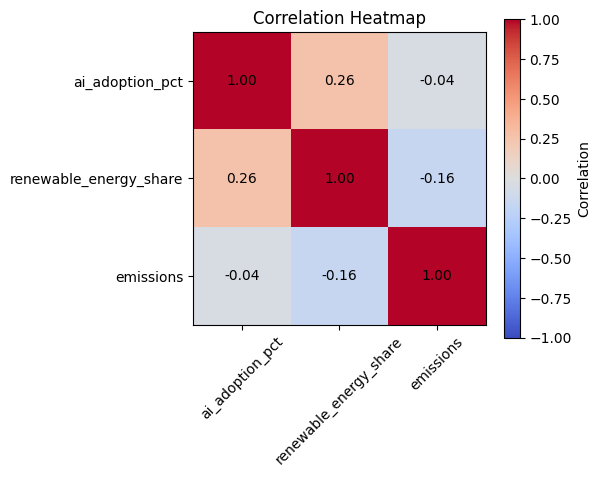

In [46]:
import matplotlib.pyplot as plt

# Select only the numeric variables
corr = grouped_df[
    ["ai_adoption_pct", "renewable_energy_share", "emissions"]
].corr()

# Plot the correlation heatmap
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(label="Correlation")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
#Interpretation
#AI Adoption vs Renewable Energy Share (0.26)
There is a weak positive correlation.
Countries with higher AI adoption tend to have slightly higher shares of renewable energy, but the relationship is not strong.
#AI Adoption vs CO₂ Emissions (-0.04)
There is almost no correlation.
Countries with higher AI adoption do not consistently have either higher or lower CO₂ emissions.
#Renewable Energy Share vs CO₂ Emissions (-0.16)
There is a very weak negative correlation.
Countries with higher renewable energy shares tend to have slightly lower CO₂ emissions, but the relationship is weak.

In [47]:
# Create AI Adoption Rank
grouped_df["ai_adoption_rank"] = (
    grouped_df["ai_adoption_pct"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

# Create Sustainability Category
renewable_median = grouped_df["renewable_energy_share"].median()
emissions_median = grouped_df["emissions"].median()

def sustainability(row):
    if (
        row["renewable_energy_share"] >= renewable_median
        and row["emissions"] <= emissions_median
    ):
        return "High"
    elif (
        row["renewable_energy_share"] < renewable_median
        and row["emissions"] > emissions_median
    ):
        return "Low"
    else:
        return "Medium"

grouped_df["sustainability_category"] = grouped_df.apply(sustainability, axis=1)

# Create the scorecard
scorecard = grouped_df[[
    "geo",
    "year",
    "ai_adoption_rank",
    "renewable_energy_share",
    "emissions",
    "sustainability_category"
]].sort_values("ai_adoption_rank")

# Display it
scorecard.head(10)

,geo,year,ai_adoption_rank,renewable_energy_share,emissions,sustainability_category
40,DK,2024,1,46.461,5.95920,High
41,DK,2024,1,46.461,5959.20000,Medium
154,SE,2024,2,62.846,7.99016,High
155,SE,2024,2,62.846,7990.16000,Medium
10,BE,2024,3,14.336,14.68376,Medium
11,BE,2024,3,14.336,14683.76000,Low
65,FI,2024,4,52.124,8144.54000,Medium
64,FI,2024,4,52.124,8.14454,High
36,DK,2021,5,41.494,8.16465,High
37,DK,2021,5,41.494,8164.65000,Medium


In [ ]:
#The scorecard shows that:

#Denmark (DK) ranks first in AI adoption and has a relatively high renewable energy share, suggesting a strong sustainability profile.
#Sweden (SE) also ranks highly in AI adoption and has the highest renewable energy share among the countries shown.
#Belgium (BE) has high AI adoption but a much lower renewable energy share, indicating that high AI adoption does not necessarily coincide with strong sustainability indicators.
#Finland (FI) combines high AI adoption with a high share of renewable energy, although its emissions should be interpreted carefully.

#Overall conclusion

The scorecard illustrates that countries with high AI adoption can also perform well on some sustainability indicators, 
particularly renewable energy use. However, the results are not consistent across all countries. This supports the findings from
the correlation analysis, which showed only a weak relationship between AI adoption and environmental sustainability.

In [52]:
corr = grouped_df[
    ["ai_adoption_pct", "renewable_energy_share", "emissions"]
].corr()

print(corr)

                        ai_adoption_pct  renewable_energy_share  emissions
ai_adoption_pct                 1.00000                0.262120  -0.044580
renewable_energy_share          0.26212                1.000000  -0.155598
emissions                      -0.04458               -0.155598   1.000000


In [ ]:
#Correlation results
#Variables	Correlation	Interpretation
AI Adoption ↔ Renewable Energy	0.262:	Weak positive relationship
AI Adoption ↔ CO₂ Emissions	-0.045:	Almost no relationship
Renewable Energy ↔ CO₂ Emissions	-0.156:	Weak negative relationship

In [ ]:
#Interpretation
#AI adoption and renewable energy (0.262): Countries with higher AI adoption tend to have slightly higher shares of renewable energy, but the relationship is weak.
#AI adoption and CO₂ emissions (-0.045): There is essentially no linear relationship. Higher AI adoption is not associated with noticeably lower (or higher) emissions.
#Renewable energy and CO₂ emissions (-0.156): Countries with more renewable energy tend to have slightly lower emissions, but again the relationship is weak.

In [ ]:
#Based on this analysis:

#The findings do not provide strong evidence that Europe's AI boom is either environmentally sustainable or unsustainable. 
#Countries with higher AI adoption tend to have slightly higher shares of renewable energy (correlation = 0.26), 
#but AI adoption shows virtually no relationship with CO₂ emissions (correlation = -0.04). 
#This suggests that a country's environmental performance is influenced more by its energy mix and climate policies than by its level of AI adoption alone.